In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

class Markov:
    def __init__(self,bCPP=True):
        self.bCPP = bCPP
        self.iNrStates = None
        self.iMaxTime  = None    
        self.dPij = []
        self.dPre = []
        self.dPost= []
        self.dv   = []
        self.dDK  = []
        self.dCF  = []
        self.bCalculated = False
        self.bCFCalculated = False
        self.iStart = None
        self.iStop  = None
        self.iNrTimesPerPeriod = 1.
        self.bRecalculateTime = False
        self.psymM = None
    
    def vDefineModel(self,iNrStates,iMaxTime=1200):
        self.iNrStates = iNrStates
        self.iMaxTime = iMaxTime
        #print("..",self.iNrStates,self.iMaxTime)
        try:
            import omarkov as mlv
            if self.bCPP:
                
                self.psymM = mlv.MARKOVLV(self.iMaxTime,self.iMaxTime,1)
                license_str = open("/Users/michaelkoller/Documents/michael_2039.lic").read().strip()
                if mlv.iSetLicense(license_str) != 1:
                    raise RuntimeError("markovlv:␣invalid␣or␣expired␣license")

                strTables = "tables.json"

                print(mlv.iAddTables(strTables))
                self.psymM.vSetNrStates(iNrStates)
                return()
        except:
            print("Falling Back")
        for i in range(iMaxTime):
                tempPij = np.zeros([iNrStates,iNrStates])
                tempPost = np.zeros([iNrStates,iNrStates])
                tempPre = np.zeros([iNrStates])
                tempDK = np.zeros([iNrStates])
                tempCF = np.zeros([iNrStates])
                self.dPij.append(tempPij)
                self.dPost.append(tempPost)
                self.dPre.append(tempPre)
                self.dDK.append(tempDK)
                self.dCF.append(tempCF)         
        tempv = np.zeros([iMaxTime])
        self.dv=tempv
    
    def vSetDiscount(self,fIRate):
        vTemp = 1./(1.+fIRate)
        #print("Discount %.4f"%(vTemp))
        #print (self.iMaxTime, len(self.dv))
        for i in range(self.iMaxTime):
            if self.psymM:
                for j in range(self.iNrStates):
                    self.psymM.dSetDisc(i, j, j, vTemp)
            else:
                self.dv[i] = vTemp
        self.bCalculated = False
        self.bCFCalculated = False
    
    def vSetPij(self,t,i,j,fValue):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.dSetPij(t,i,j,fValue)
        else:
            self.dPij[t][i,j] = fValue
        self.bCalculated = False
        self.bCFCalculated = False
    
    def vSetPre(self,t,i,j,fValue):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.dSetPre(t,i,j,fValue)
        else:
            self.dPre[t][i] = fValue
        self.bCalculated = False
        self.bCFCalculated = False
    
    def vSetPost(self,t,i,j,fValue):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.dSetPost(t,i,j,fValue)
        else:
            self.dPost[t][i,j] = fValue
        self.bCalculated = False
        self.bCFCalculated = False
    
    def pymBlowMeUp(self,iNrTimesPerPeriod,DefaultStateMapper = dict()):
        psymM = Markov()
        psymM.vDefineModel(self.iNrStates,iMaxTime=self.iMaxTime*iNrTimesPerPeriod)
        psymM.iNrTimesPerPeriod = iNrTimesPerPeriod
        psymM.bRecalculateTime = False
        self.vDoBlowUpStates(psymM,DefaultStateMapper) #To be done ie adjustment of v, P_ij, Pre and Post
        return(psym)
    
    def vDoBlowUpStates(self,psymM,DefaultStateMapper):
        for i in range(self.iNrStates):
            if i not in DefaultStateMapper.keys():
                print("Use %d to itself as default mapper"%(i))
                DefaultStateMapper[i] = i
        fIRate = 1./self.dv[0] - 1.
        psymM.vSetDiscount(fIRate)
        for t in range(self.iMaxTime):
            t0 = self.iMaxTime *self.iNrTimesPerPeriod
            t1 = t0 + self.iNrTimesPerPeriod
            for i in range(self.iNrStates):
                x=[t0*1,t1*1]
                y=[self.dPre[t][i],self.dPost[t][i,i]]
                newval = np.interp(list(range(t0,t1+1))*1., x, y)
                dPDefault  = 1.
                PTemp = np.zeros(self.iNrStates)
                for l in range(self.iNrStates):
                    if l == DefaultStateMapper[i]: continue
                    dTemp = self.dPij[t][i,l] / self.iNrTimesPerPeriod
                    dPDefault  -= dTemp
                    PTemp[l] = dTemp
                PTemp[DefaultStateMapper[i]] = PTemp[l]  
                for k in range(t1-t0):
                    psymM.vSetPre(t0+k,i,i,newval[k])
                    psymM.vSetPij(t0+k,i,l,PTemp[l])
                    for l in range(self.iNrStates):
                        if i == l: continue
                        psymM.vSetPost(t0+k,i,l,self.dPost[t][i,l])
                psymM.vSetPost(t1-1,i,i,newval[-1])
                
                
                
                    
                
    
    def doCalculateDK(self,iStart,iStop,iAge,iState):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        self.iStop = iStop
        self.iStart = iStart
        self.bCalculated = True
        for i in range(self.iMaxTime):
            self.dDK[i] *= 0.
        
        for i in range(self.iStart-1, self.iStop-1,-1):
            #print("Calc Time", i)
            for j in range(self.iNrStates):
                self.dDK[i][j] = self.dPre[i][j]
                for k in range(self.iNrStates):
                    self.dDK[i][j] += self.dv[i]*self.dPij[i][j,k]*(self.dPost[i][j,k]+self.dDK[i+1][k])
    
    def doCalculateCF(self,iStart,iStop,iAge,iState,bTrace=False):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        self.iStop = iStop
        self.iStart = iStart
        self.bCFCalculated = True
        for i in range(self.iMaxTime):
            self.dCF[i] *= 0.
        
        CurrentP = np.asmatrix(np.identity(self.iNrStates))
        if bTrace:
            print("----- ----- ----- ----- ")
        for i in range(self.iStop, self.iStart):
            if bTrace:
                print("----- ----- ----- ----- ")
                print(" Time ", i)
                print("CF BoP", self.dCF[i])
            for k in range(self.iNrStates):
                for l in range(self.iNrStates):
                    self.dCF[i][k] += CurrentP[k,l] * self.dPre[i][l]
            if bTrace:
                print("CF BoP after Pre", self.dCF[i])
            NextP = np.asmatrix(self.dPij[i])
            if bTrace:
                print("+++++ +++++ +++++ ")
                print("CurrentP\n", CurrentP) 
                print("+++++ +++++ +++++ ")
                print("Next P\n", NextP) 
                print("+++++ +++++ +++++ ")
                
            for k in range(self.iNrStates):
                for l in range(self.iNrStates):
                    for m in range(self.iNrStates):
                        self.dCF[i+1][k] += CurrentP[k,l] * NextP[l,m] * self.dPost[i][l,m]
            if bTrace:
                print("CF EoP t", self.dCF[i])
                print("CF EoP t+1", self.dCF[i+1])
            
            CurrentP = CurrentP * NextP
            if bTrace:
                print("+++++ +++++ +++++ ")
                print("CurrentP EoP\n", CurrentP) 
                print("+++++ +++++ +++++ ")
    
    def dGetDK(self,iStart,iStop,iAge,iState):       
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.vSetStartTime(iStart)
            self.psymM.vSetStopTime(iStop)
            return(self.psymM.dGetDK(iAge, iState,1))
        if (iStart != self.iStart or iStop != self.iStop or not(self.bCalculated)):
            self.doCalculateDK(iStart,iStop,iAge,iState)
        return(self.dDK[iAge][iState])

    def dGetCF(self,iStart,iStop,iAge,iState):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.vSetStartTime(iStart)
            self.psymM.vSetStopTime(iStop)
            dT = 0
            for j in range(self.iNrStates):
                dT+=self.psymM.dGetCF(iAge, iState, j)
            return(dT)
        if (not(self.bCFCalculated) or self.iStart != iStart or self.iStop != iStop ):
            self.doCalculateCF(iStart,iStop,iAge,iState)
        return(self.dCF[iAge][iState])
    
    def PrintDKs(self,iStart,iStop):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        for i in range(iStop,iStart+1):
            strTemp = " %3d :"%(i)
            if self.bRecalculateTime: 
                strTemp += " %6.3f :"%(i*1./self.iNrTimesPerPeriod)
            for j in range(self.iNrStates):
                 strTemp += "   %10.4f  "%(self.dGetDK(iStart,iStop,i,j))
            print(strTemp)
    
    def PlotDKs(self,iStart,iStop,figNr=1):
        if self.bRecalculateTime: 
        #    iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        x = []
        y = []
        for i in range(iStop,iStart+1):
            if self.bRecalculateTime:
                x.append(i*1./self.iNrTimesPerPeriod)
            else:
                x.append(i)
            ytemp = np.zeros(self.iNrStates)
            for j in range(self.iNrStates):
                ytemp[j] = self.dGetDK(iStart,iStop,i,j)
            y.append(ytemp)
        plt.figure(figNr)
        plt.plot(x,y)
        plt.grid(True)
        
    def PlotCFs(self,iStart,iStop,figNr=2):
        if self.bRecalculateTime: 
        #    iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        import matplotlib.colors as mcolors
        A= []
        for i in mcolors.TABLEAU_COLORS.keys():
            A.append(i)
        for i in mcolors.BASE_COLORS.keys():
            A.append(i)
        
        xBar =[]
        hBar =[]
        bBar =[]
        cBar =[]
        y = []
        for i in range(iStop,iStart+1):
            for j in range(self.iNrStates):
                xBar.append(i+(0.5+j)*0.9/self.iNrStates)
                hBar.append(self.dGetCF(iStart,iStop,i,j))
                bBar.append(0)
                cBar.append(A[j])
            
        plt.figure(figNr)
        plt.bar(xBar,hBar,bottom=bBar, width = 0.9/self.iNrStates,color=cBar)
        plt.grid(True)


In [12]:
def Qx(gender,x,t,param =[]):
    # This is our default mortality
    if gender == 0:
        a =[2.34544649e+01,8.70547812e-02,7.50884047e-05,-1.67917935e-02]
    else:
        a =[2.66163571e+01,8.60317509e-02,2.56738012e-04,-1.91632675e-02]
    return(np.exp(a[0]+(a[1]+a[2]*x)*x+a[3]*t))

class Annuity(Markov):
    def __init__(self, NrPayments = 1, bPre=True,iRate = 0.02,PaymentStart=0,PaymentEnd=120,Benefit =1):
        psymSuper = super()
        self.psymSuper = psymSuper
        psymSuper.__init__()
        if bPre:
            self.fPre = (NrPayments + 1.)/(2*NrPayments) * Benefit
        else:
            self.fPre = (NrPayments - 1.)/(2*NrPayments) * Benefit
        self.fPost = Benefit - self.fPre
        v = 1./(1.+iRate)
        self.iMaxTime=120
        psymSuper.vDefineModel(2,iMaxTime=self.iMaxTime)
        psymSuper.vSetDiscount(iRate)
        for t in range(self.iMaxTime):
            if t>= PaymentStart and t < PaymentEnd:
                psymSuper.vSetPre(t,0,0,self.fPre)
                psymSuper.vSetPost(t,0,0,self.fPost)

    def dSetQx(self,age,qx):
        self.psymSuper.vSetPij(age,0,0,1-qx)
        self.psymSuper.vSetPij(age,0,1,qx)
        
    def dGetaex(self,age):
        return(self.psymSuper.dGetDK(self.iMaxTime-1,0,age,0))
    
class Capital(Markov):
    def __init__(self, iRate = 0.02,PaymentStart=0,PaymentEnd=120, Maturity =120, BenDeath = 1, BenEndowment=1):
        psymSuper = super()
        self.psymSuper = psymSuper
        psymSuper.__init__()
        v = 1./(1.+iRate)
        self.iMaxTime=120
        PaymentEnd = min(PaymentEnd,Maturity)
        psymSuper.vDefineModel(2,iMaxTime=self.iMaxTime)
        psymSuper.vSetDiscount(iRate)
        for t in range(self.iMaxTime):
            if t>= PaymentStart and t < PaymentEnd:
                psymSuper.vSetPost(t,0,1,BenDeath)
        psymSuper.vSetPre(Maturity,0,1,BenEndowment)

    def dSetQx(self,age,qx):
        self.psymSuper.vSetPij(age,0,0,1-qx)
        self.psymSuper.vSetPij(age,0,1,qx)
        
    def dGetAx(self,age):
        return(self.psymSuper.dGetDK(self.iMaxTime-1,0,age,0))
        

Falling Back
Falling Back
12302.976099214853 86253.38440242843 7.0107739547614765
80 0.048800745777206785
81 0.05388701875150919
82 0.05951234681884902
83 0.06573478047254111
84 0.07261871807653629
85 0.0802356102928641
86 0.08866474379388845
87 0.09799411330562403
88 0.10832139207421533
89 0.11975501201598168
90 0.13241536611673213


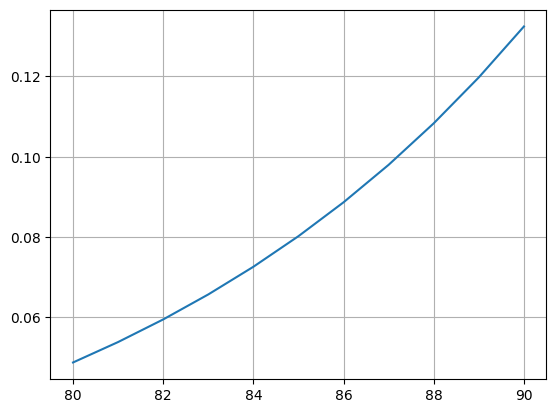

In [13]:
s=90
psymB = Capital(PaymentEnd=s, Maturity =s,BenDeath = 1e5, BenEndowment=1e5)
psymP = Annuity(PaymentStart=0,PaymentEnd=s)
for i in range(120):
    psymB.dSetQx(i,Qx(0,i,2020))
    psymP.dSetQx(i,Qx(0,i,2020))
x=80
iRate1=0.02
iRate2=0.03
Premium = psymB.dGetAx(x)/psymP.dGetaex(x)
print(Premium,psymB.dGetAx(x),psymP.dGetaex(x))

xPlot=[]
yPlot=[]

import matplotlib.pyplot as plt
for i in range(x,s+1):
    xPlot.append(i)
    yPlot.append(Qx(0,i,2020))
    print(i, Qx(0,i,2020))
    
plt.plot(xPlot,yPlot)
plt.grid(True)
    

In [14]:
psi =[0]
for i in range(x,s):
    psi.append((psymB.dGetAx(i+1) - Premium * psymP.dGetaex(i+1))/psymB.dGetAx(i+1))
    print("t %2d: %10.2f"%(i,psi[-1]*1.e5))
psi.append(1.)



t 80:    9228.77
t 81:   18375.48
t 82:   27498.51
t 83:   36670.15
t 84:   45980.83
t 85:   55545.00
t 86:   65509.06
t 87:   76062.14
t 88:   87450.96
t 89:  100000.00


12302.976099214853 12302.976099214853 1.0


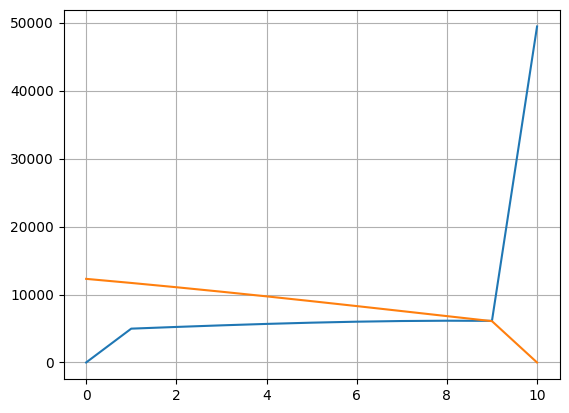

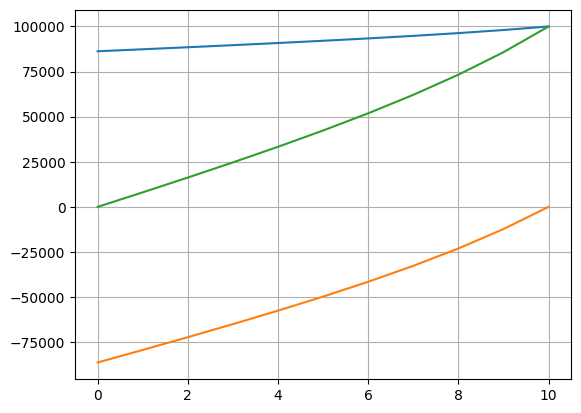

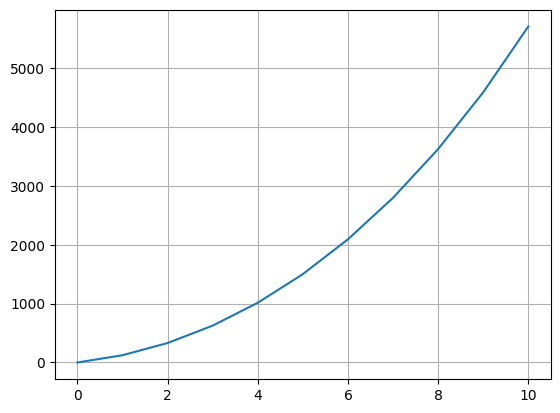

In [15]:
psymBCF = np.zeros(s+1-x)
psymPCF = np.zeros(s+1-x)
psymBDK = np.zeros(s+1-x)
psymPDK = np.zeros(s+1-x)
psymBBank = np.zeros(s+1-x)

for i in range(x,s+1):
    if i< s:
        psymBCF[i-x] = psymB.dGetCF(s+1,x,i,0)*(1+iRate1)
    else:
          psymBCF[i-x] = psymB.dGetCF(s+1,x,i,0)
    psymPCF[i-x] = Premium*psymP.dGetCF(s+1,x,i,0)
    psymBDK[i-x] = psymB.dGetAx(i)
    psymPDK[i-x] = Premium*psymP.dGetaex(i)
    if i>x:
       psymBBank[i-x]=psymBBank[i-1-x]*(1+iRate2)+ (psymBDK[i-1-x]-psymPDK[i-1-x]+Premium) * (iRate2- iRate1)
 
print(Premium,psymPCF[0],psymPCF[0]/Premium)

import matplotlib.pyplot as plt
plt.figure(1)
plt.plot(range(len(psymBCF)),psymBCF,range(len(psymPCF)),psymPCF)
plt.grid(True)

plt.figure(2)
plt.plot(range(len(psymBDK)),psymBDK,range(len(psymPDK)),-psymPDK,range(len(psymPDK)),psymBDK-psymPDK)
plt.grid(True)

plt.figure(3)
plt.plot(range(len(psymBBank)),psymBBank)
plt.grid(True)

<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/01/3sx_949s1jq1p4b651lcq1sm0000gn/T/ipykernel_23186/1014828041.py:7: SyntaxWarning: invalid escape sequence '\Z'
  50 & $\ZCB{0}$ & --      & -9562.20 & -9562.20 & -9562.20 & -9562.20 \\
/var/folders/01/3sx_949s1jq1p4b651lcq1sm0000gn/T/ipykernel_23186/1014828041.py:20: SyntaxWarning: invalid escape sequence '\m'
  strLine2 = "%d & $\mathcal{H}_{(%s)}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"
/var/folders/01/3sx_949s1jq1p4b651lcq1sm0000gn/T/ipykernel_23186/1014828041.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Spectral')
/var/folders/01/3sx_949s1jq1p4b651lc

{\bf Cash flow induced by Premium at age 80} \\ 

{\bf Cash flow induced by Premium at age 81} \\ 

{\bf Cash flow induced by Premium at age 82} \\ 

{\bf Cash flow induced by Premium at age 83} \\ 

{\bf Cash flow induced by Premium at age 84} \\ 

{\bf Cash flow induced by Premium at age 85} \\ 

{\bf Cash flow induced by Premium at age 86} \\ 

{\bf Cash flow induced by Premium at age 87} \\ 

{\bf Cash flow induced by Premium at age 88} \\ 

{\bf Cash flow induced by Premium at age 89} \\ 

{\bf Cash flow induced by all Premiums} \\ 

{\bf Cash flow induced by Premium at age 80} \\ 

\begin{center}
\begin{tabular}{ccrrrrr}
Age & Unit & Units for & Units for & Total & Value & Value \\
 &  & Mortality & Premium& Units & $i = 2\%$ & $i = 4\%$ \\[1ex] 
80 & $\ZCB{0^+}$ &      0.00 & -12302.98 & -12302.98 & -12302.98 & -12302.98 \\
80 & $\ZCB{1^-}$ &      0.00 &      0.00 &      0.00 &      0.00 &      0.00 \\
81 & $\ZCB{2^-}$ &    459.38 &      0.00 &    459.38 &    441.54 &    424.72 

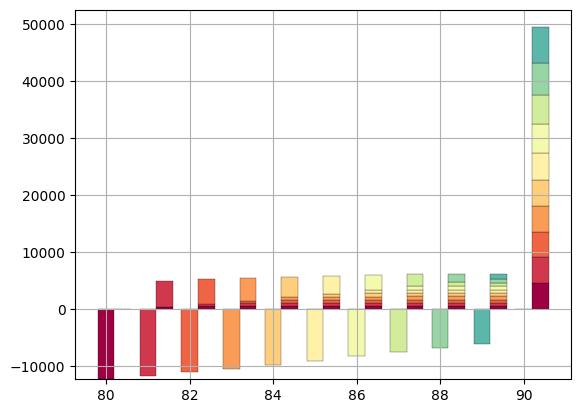

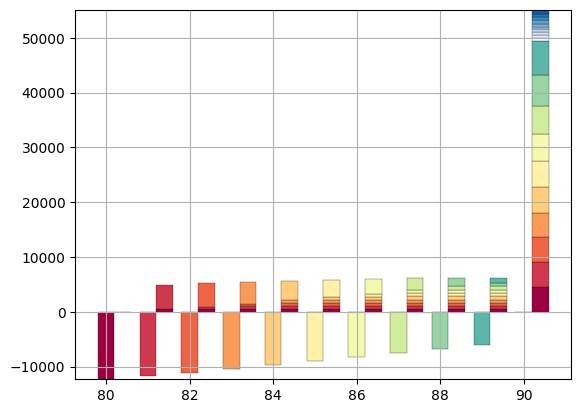

In [16]:
strTableStart = """
\\begin{center}
\\begin{tabular}{ccrrrrr}
Age & Unit & Units for & Units for & Total & Value & Value \\\\
 &  & Mortality & Premium& Units & $i = 2\\%$ & $i = 4\\%$ \\\\[1ex] \n"""
AllLines = """
50 & $\ZCB{0}$ & --      & -9562.20 & -9562.20 & -9562.20 & -9562.20 \\
51 & $\ZCB{1}$ & 1019.67 & -8797.22 & -7777.54 & -7625.04 & -7478.40 \\
52 & $\ZCB{2}$ & 1594.01 & -8084.65 & -6490.63 & -6238.59 & -6000.95 \\
53 & $\ZCB{3}$ & 2066.98 & -7421.70 & -5354.72 & -5045.87 & -4760.33 \\
54 & $\ZCB{4}$ & 2449.23 & -6805.70 & -4356.47 & -4024.71 & -3723.93 \\
55 & $\ZCB{5}$ & 2750.73 & -6234.02 & -3483.29 & -3154.92 & -2863.01 \\
56 & $\ZCB{6}$ & 2980.77 & -5704.13 & -2723.35 & -2418.26 & -2152.31 \\
57 & $\ZCB{7}$ & 3147.94 & -5213.57 & -2065.63 & -1798.25 & -1569.71 \\
58 & $\ZCB{8}$ & 3260.18 & -4759.99 & -1499.81 & -1280.07 & -1095.89 \\
59 & $\ZCB{9}$ & 3324.77 & -4341.11 & -1016.34 & -850.42  & -714.06 \\
60 & $\ZCB{10}$& 5486.26 & 42159.27 & 47645.53 & 39085.93 & 32187.61 \\
"""
strLine = "%d & $\\ZCB{%s}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"
strLine2 = "%d & $\mathcal{H}_{(%s)}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"

strTotal ="{\\bf Total} &  &  &  &  & {\\bf %9.2f} & {\\bf %9.2f} \\\\"
strTableEnd = """
\\end{tabular}
\\end{center}
"""

strLatex = ""

strName="examplenatprem.png"
strName2="examplenatprem2.png"
xx=[]
y=[]
b=[]
c=[]
w=[]
import matplotlib
cmap = matplotlib.cm.get_cmap('Spectral')
cmap2 = matplotlib.cm.get_cmap('Blues')
cmap3 = matplotlib.cm.get_cmap('Greens')
for i in range(x,s+1):
    xx.append(i)
    y.append(psymPCF[i-x])
    c.append(cmap((i-x)*1./(s+1-x)))
    b.append(-psymPCF[i-x])
    w.append(0.4)
for i in range(x,s):
    for j in range(i,s+1):
        xx.append(j+0.4)
        if i==j:
            dBen = psymBCF[j-x]*(1.-psi[i-x])
            loccol = cmap((i-x)*1./(s+1-x))
        else:
            dBen = psymBCF[j-x]*(psi[i+1-x]-psi[i-x])
            loccol = cmap((i-x)*1./(s+1-x))
        y.append(dBen)
        c.append(loccol)
        b.append(psymBCF[j-x]*(psi[i-x]))
        w.append(0.4)
        #if j==65: print(i,xx[-1],y[-1],b[-1])

dT2 =[]
dT4 =[]


        
for i in range(x,s):
    dTot2 = 0
    dTot4 = 0
    strTitle = "{\\bf Cash flow induced by Premium at age %d} \\\\ \n"%(i)
    print(strTitle)
    strLatex += strTitle + strTableStart
    dBen = 0
    iAge = i
    strSym = "%d^+"%(i-x)
    dPrem = -psymPCF[i-x]
    dTot = dBen + dPrem
    dPart2 = dTot * (1.02)**(-(i-x))
    dPart4 = dTot * (1.04)**(-(i-x))
    strLatex += strLine %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
    dTot2 += dPart2 
    dTot4 += dPart4
    # Age & Unit & Units for & Units for & Total & Value & Value \\
    #         &  & Mortality & Premium& Units & $i = 2\%$ & $i = 4\%$ \\[1ex]    
    # strLine = "50 & $\ZCB{%s}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\"
    for j in range(i,s+1):
        if i==j:
            dBen = psymBCF[j-x]*(1.-psi[i-x])
        else:
            dBen = psymBCF[j-x]*(psi[i+1-x]-psi[i-x])
        dPrem = 0
        dTot = dBen + dPrem
        iAge = j
        if j < s:
            strSym = "%d^-"%(j-x+1)
            dPart2 = dTot * (1.02)**(-(j-x+1))
            dPart4 = dTot * (1.04)**(-(j-x+1))
            strLatex += strLine %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
        else:
            strSym = "%d^+"%(j-x)
            dPart2 = dTot * (1.02)**(-(j-x))
            dPart4 = dTot * (1.04)**(-(j-x))
            strLatex += strLine %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
            
        dTot2 += dPart2 
        dTot4 += dPart4
    strLatex += strTotal%(dTot2,dTot4) +"\n"
    strLatex += strTableEnd + "\n"
    dT2.append(dTot2)
    dT4.append(dTot4)

dTot2 = 0
dTot4 = 0

strTitle = "{\\bf Cash flow induced by all Premiums} \\\\ \n"
print(strTitle)
strLatex += strTitle + strTableStart

for i in range(x,s+1):
    dBen = 0
    iAge = i
    strSym = "%d^+"%(i-x)
    dPrem = -psymPCF[i-x]
    dTot = dBen + dPrem
    dPart2 = dTot * (1.02)**(-(i-x))
    dPart4 = dTot * (1.04)**(-(i-x))
    strLatex += strLine %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
    dTot2 += dPart2 
    dTot4 += dPart4
    # Age & Unit & Units for & Units for & Total & Value & Value \\
    #         &  & Mortality & Premium& Units & $i = 2\%$ & $i = 4\%$ \\[1ex]    
    # strLine = "50 & $\ZCB{%s}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\"
    dBen = psymBCF[i-x]
    dPrem = 0
    dTot = dBen + dPrem
    iAge = i
    if i < s:
            strSym = "%d^-"%(i-x+1)
            dPart2 = dTot * (1.02)**(-(i-x+1))
            dPart4 = dTot * (1.04)**(-(i-x+1))
            strLatex += strLine %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
    else:
            strSym = "%d^+"%(i-x)
            dPart2 = dTot * (1.02)**(-(i-x))
            dPart4 = dTot * (1.04)**(-(i-x))
            strLatex += strLine %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
            
    dTot2 += dPart2 
    dTot4 += dPart4
strLatex += strTotal%(dTot2,dTot4) +"\n"
strLatex += strTableEnd + "\n"
    
strTitle = "{\\bf Policyholder Bonus Parts} \\\\ \n"
strLatex += strTitle + strTableStart

for i in range(len(dT2)):
        Age = x + i
        strSym = str(i)
        dBen = 0 
        dPrem = 0 
        dTot = dT2[i]
        dPart2 = dT2[i]   
        dPart4 = dT4[i]
        strLatex += strLine2 %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
strLatex += strTotal%(sum(dT2),sum(dT4)) +"\n"
strLatex += strTableEnd + "\n"
    
plt.figure(1)
plt.bar(xx,y,bottom=b,color=c,width=w,edgecolor="k",linewidth=0.2)
plt.grid(True)
plt.savefig(strName,dpi=1200)

for i in range(x,s+1):
    xx.append(s+0.4)
    y.append(psymBBank[s-x]*(psi[i+1-x]-psi[i-x]))
    c.append(cmap2((i-x)*1./(s+1-x)))
    b.append(psymBCF[s-x]+psymBBank[s-x]*(psi[i-x]))
    w.append(0.4)

plt.figure(2)
plt.bar(xx,y,bottom=b,color=c,width=w,edgecolor="k",linewidth=0.2)
plt.grid(True)
plt.savefig(strName2,dpi=1200)

print(strLatex)

In [17]:
import copy
def CalcBonusCF(psymBCF, psymPCF,psymBDK, psymPDK, iDisc = 0.02, iTarif= 0.02, iBonus = 0.02,t=0):
    psymBBank = np.zeros(s+1-x)
    psymKRD = np.zeros(s+1-x)

    for i in range(x+t+1,s+1):
       psymBBank[i-x]=psymBBank[i-1-x]*(1+iBonus)+ (psymBDK[i-1-x]-psymPDK[i-1-x]+Premium) * (iBonus- iTarif)
    psymKRD[-1] += psymBBank[-1]
    for i in range(x+t,s+1):
        if i == s: psymKRD[i-x] = psymBBank[-1]
        psymKRD[i-x] += psymBCF[i-x]- psymPCF[i-x]
        psymKRD[i-x] *= ((1+iDisc)**(-(s-x-t))) - ((1+iDisc+0.0001)**(-(s-x-t)))
        
    
    
    dValueGuarantee = dPV(psymBCF-psymPCF,iDisc,t=t)
    dValueBonus =dValueGuarantee+psymBBank[s-x] * (1+iDisc)**(-(s-x-t))
    return(psymBBank,dValueGuarantee,dValueBonus,psymKRD)

def dPV(dCF,iDisc,t=0):
    PV = 0.
    for i in range(t,dCF.size): PV += dCF[i] * (1+iDisc)**(-i)
    return(PV)

#print(CalcBonusCF(psymBCF, psymPCF,psymBDK, psymPDK, iDisc = 0.02, iTarif= 0.02, iBonus = 0.04))

In [18]:
t=20
xx = np.arange(0,0.06,0.0005)
y = np.zeros(xx.size)
y2 = np.zeros(xx.size)
y3= np.zeros(xx.size)
for i in range(xx.size): 
    y[i] =  CalcBonusCF(psymBCF, psymPCF,psymBDK, psymPDK, iDisc = 0.02, iTarif= 0.02, iBonus = xx[i],t=t)[2]
    y2[i] =  CalcBonusCF(psymBCF, psymPCF,psymBDK, psymPDK, iDisc = xx[i], iTarif= 0.02,iBonus=0.02,t=t )[2]
    y3[i] =  CalcBonusCF(psymBCF, psymPCF,psymBDK, psymPDK, iDisc = xx[i], iTarif= 0.02, iBonus = xx[i],t=t)[2]
    

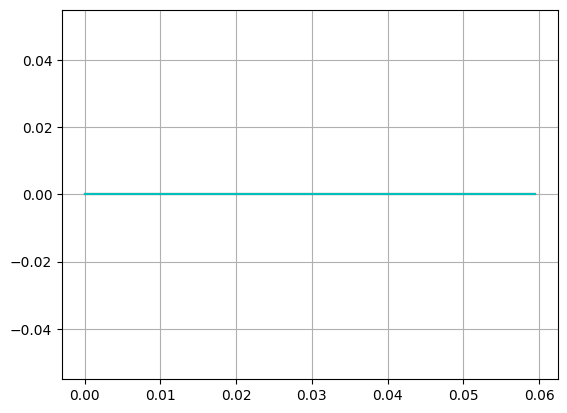

In [19]:
plt.plot(xx,y,'r',xx,y2,'g',xx,y3,'c')
plt.grid(True)

In [20]:
strTableStart3 = """
\\begin{center}
\\begin{tabular}{ccrrrrr}
Age & Unit & Part for & Units for & Total & Value & Value \\\\
    &      & Paid Out & Bonus     & Units & $i = 2\\%$ & $i = 4\\%$ \\\\[1ex] \n"""
AllLines = """
50 & $\ZCB{0}$ &      -- & -9562.20 & -9562.20 & -9562.20 & -9562.20 \\
51 & $\ZCB{1}$ & 1019.67 & -8797.22 & -7777.54 & -7625.04 & -7478.40 \\
52 & $\ZCB{2}$ & 1594.01 & -8084.65 & -6490.63 & -6238.59 & -6000.95 \\
53 & $\ZCB{3}$ & 2066.98 & -7421.70 & -5354.72 & -5045.87 & -4760.33 \\
54 & $\ZCB{4}$ & 2449.23 & -6805.70 & -4356.47 & -4024.71 & -3723.93 \\
55 & $\ZCB{5}$ & 2750.73 & -6234.02 & -3483.29 & -3154.92 & -2863.01 \\
56 & $\ZCB{6}$ & 2980.77 & -5704.13 & -2723.35 & -2418.26 & -2152.31 \\
57 & $\ZCB{7}$ & 3147.94 & -5213.57 & -2065.63 & -1798.25 & -1569.71 \\
58 & $\ZCB{8}$ & 3260.18 & -4759.99 & -1499.81 & -1280.07 & -1095.89 \\
59 & $\ZCB{9}$ & 3324.77 & -4341.11 & -1016.34 & -850.42  &  -714.06 \\
60 & $\ZCB{10}$& 5486.26 & 42159.27 & 47645.53 & 39085.93 & 32187.61 \\
"""
strLine = "%d & $\\ZCB{%s}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"
strLine2 = "%d & $\mathcal{H}_{(%s)}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"
strLine3 = "%d & %s & %9.5f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"

strTotal3 ="{\\bf Total} &  &  &  &  & {\\bf %9.2f} & {\\bf %9.2f} \\\\"
strTableEnd3 = """
\\end{tabular}
\\end{center}
"""

<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/01/3sx_949s1jq1p4b651lcq1sm0000gn/T/ipykernel_23186/2410254165.py:7: SyntaxWarning: invalid escape sequence '\Z'
  50 & $\ZCB{0}$ &      -- & -9562.20 & -9562.20 & -9562.20 & -9562.20 \\
/var/folders/01/3sx_949s1jq1p4b651lcq1sm0000gn/T/ipykernel_23186/2410254165.py:20: SyntaxWarning: invalid escape sequence '\m'
  strLine2 = "%d & $\mathcal{H}_{(%s)}$ & %9.2f & %9.2f & %9.2f & %9.2f & %9.2f \\\\"


In [21]:
strBonStrategy1 = ""
fTotalBonus = 1132.86
ecf = []
tpx = 1.
nomalisator = 0.
t = 0
for i in range(x,s):
    qx= Qx(0,i,2020)
    ecf.append(tpx * qx)
    tpx *= (1.-qx)
    nomalisator += ecf[-1] * (1.04)**(-(t+1))
    t +=1
ecf.append(tpx)
nomalisator += ecf[-1] * (1.04)**(-(t))
print(ecf)
print(sum(ecf))
strBonStrategy1 += strTableStart3
t = 0
dTot2 = 0
dTot4 = 0
for i in range(x,s):
        Age = x 
        strSym = "$\\ZCB{%s}$"%(str(t+1))
        dBen = ecf[t]
        dPrem = ecf[t] * fTotalBonus / nomalisator
        dTot = dPrem
        dPart2 = dPrem * (1.02)**(-(t+1))   
        dPart4 = dPrem * (1.04)**(-(t+1))  
        dTot2 += dPart2
        dTot4 += dPart4
        t+=1
        strBonStrategy1 += strLine3 %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
Age = s 
strSym = "$\\ZCB{%s}$"%(str(t))
dBen = ecf[t]
dPrem = ecf[t] * fTotalBonus / nomalisator
dTot = dPrem
dPart2 = dPrem * (1.02)**(-(t))   
dPart4 = dPrem * (1.04)**(-(t))  
dTot2 += dPart2
dTot4 += dPart4
strBonStrategy1 += strLine3 %(iAge, strSym, dBen, dPrem, dTot, dPart2, dPart4) +"\n"
strBonStrategy1 += strTotal3%(dTot2,dTot4) +"\n"
strBonStrategy1 += strTableEnd3 + "\n"

print(strBonStrategy1)

[np.float64(0.048800745777206785), np.float64(0.051257292048725214), np.float64(0.053557658169738634), np.float64(0.05563688641912909), np.float64(0.05742306378736877), np.float64(0.0588387270695892), np.float64(0.05980309528651988), np.float64(0.06023526963308796), np.float64(0.060058499230848224), np.float64(0.05920553220306912), np.float64(0.43518323037471723)]
1.0000000000000002

\begin{center}
\begin{tabular}{ccrrrrr}
Age & Unit & Part for & Units for & Total & Value & Value \\
    &      & Paid Out & Bonus     & Units & $i = 2\%$ & $i = 4\%$ \\[1ex] 
90 & $\ZCB{1}$ &   0.04880 &     73.83 &     73.83 &     72.38 &     70.99 \\
90 & $\ZCB{2}$ &   0.05126 &     77.54 &     77.54 &     74.53 &     71.69 \\
90 & $\ZCB{3}$ &   0.05356 &     81.02 &     81.02 &     76.35 &     72.03 \\
90 & $\ZCB{4}$ &   0.05564 &     84.17 &     84.17 &     77.76 &     71.95 \\
90 & $\ZCB{5}$ &   0.05742 &     86.87 &     86.87 &     78.68 &     71.40 \\
90 & $\ZCB{6}$ &   0.05884 &     89.01 &     89